# Analysis of different populations in mouse embryonic skin epidermal scRNA-seq profiles

Here in this notebook, we check the expression and percentage of each markers for palatal epidermal populations in mouse embryonic skin epidrmal scRNA-seq, published in Dev Cell, 2023 from Kasper Lab.

# 1 Set pwd and load datasets

In [1]:
#You are currently looking at the notebook processing/plotting keratinocytes only
cell_type = 'Epi'

In [2]:
#Load the required packages
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import os
import pandas as pd
import numpy as np
import sys
import seaborn as sbn
import scanpy as sc
import scvelo as scv
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
#import bbknn
from IPython.display import clear_output
from matplotlib.ticker import MaxNLocator
import cellrank as cr
from cellrank.kernels import VelocityKernel
from cellrank.kernels import ConnectivityKernel
#from cellrank.kernels import PalantirKernel
from cellrank.estimators import GPCCA

/tmp/ipykernel_925872/1055859536.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
# setup workdir

workdir = "/home/liuhuan/scRNAseq/mouse_embryo_skin/processed"
os.chdir(workdir)

#Set paths
path = '/home/liuhuan/scRNAseq/mouse_embryo_skin/'

In [4]:
# Load data

adata = sc.read_h5ad(os.path.join(workdir, "Adata-object_Epi.h5"))
adata

AnnData object with n_obs × n_vars = 1584 × 19994
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'simp_index', 'invsimp_index', 'shan_index', 'perc_rpl', 'perc_rps', 'perc_hb.ab.', 'perc_mito', 'perc_hba', 'perc_hbb', 'perc_hist', 'filtered', 'sample_id', 'embryonic_age', 'genotype', 'dataset', 'sample_no', 'sample_code', 'sample_date', 'library', 'sequencing', 'sex', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Diff', 'HC_1', 'HC_2', 'HC_3', 'HC_4', 'HC_5', 'HC_6', 'HC_7', 'HC_8', 'HC_9', 'HC_10', 'HC_11', 'HC_12', 'HC_13', 'HC_14', 'HC_15', 'HC_16', 'HC_17', 'HC_18', 'HC_19', 'HC_20', 'HC_21', 'HC_22', 'HC_23', 'HC_24', 'HC_25', 'HC_26', 'HC_27', 'HC_28', 'HC_30', 'HC_31', 'HC_33', 'HC_35', 'HC_37', 'HC_39', 'HC_42', 'HC_45', 'HC_49', 'HC_53', 'HC_58', 'HC_64', 'HC_72', 'HC_82', 'HC_95', 'HC_112', 'HC_138', 'HC_180', 'HC_32', 'HC_41', 'HC_40', 'HC_named'
    var: 'highly_variable'
    uns: 'HC_named_colors', 'Phase_colors', 'embryonic_age_colors', 'neighbors', 'pca', 'sampl

In [18]:
#Define function that can remove axis elements from subplots
#axes can be either an individual subplot, a list of individual subplots or mix of multiple subplots in a nested list.
def clean_axis(axes, remove_borders = True, remove_ticks = True, remove_axis_labels = True):
    axes = flatten_list(axes)
    print(axes)
    for ax in axes:
        if remove_borders:
            for loc in ['left','right','top','bottom']:
                ax.spines[loc].set_visible(False)
        if remove_ticks:
            for side in ['x','y']:
                ax.tick_params(
                    axis=side,  # changes apply to the x-axis
                    which='both',  # both major and minor ticks are affected
                    bottom=False,  # ticks along the bottom edge are off
                    top=False,  # ticks along the top edge are off
                    left=False,
                    labelbottom=False,
                    labelleft=False,
                    labeltop = False)
        if remove_axis_labels:
            ax.set_ylabel('')
            ax.set_xlabel('')

#Define function to generate a plot with multiple subplots
def initialize_subplots(groups_to_plot, ncols = 3, figsize_multiplier = (7,5), gridspec_kw = None, figsize = None, print_help = True, **fig_kw):
    if type(groups_to_plot)==list:
        total = len(groups_to_plot)
    else:
        total = groups_to_plot
    nrows = int(np.ceil(total/ncols))
    if not figsize:
        figsize = (figsize_multiplier[0]*ncols, figsize_multiplier[1]*nrows)
    fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = figsize, gridspec_kw = gridspec_kw, **fig_kw)
    if print_help:
        if nrows>1 and ncols>1:
            print('ax = axes[ix // ncols, ix % ncols]')
        else:
            print('ax = axes[ix]')
    return fig, axes

# 2 Basic plot

## 2.1 UMAP plot for all epithelial celltypes

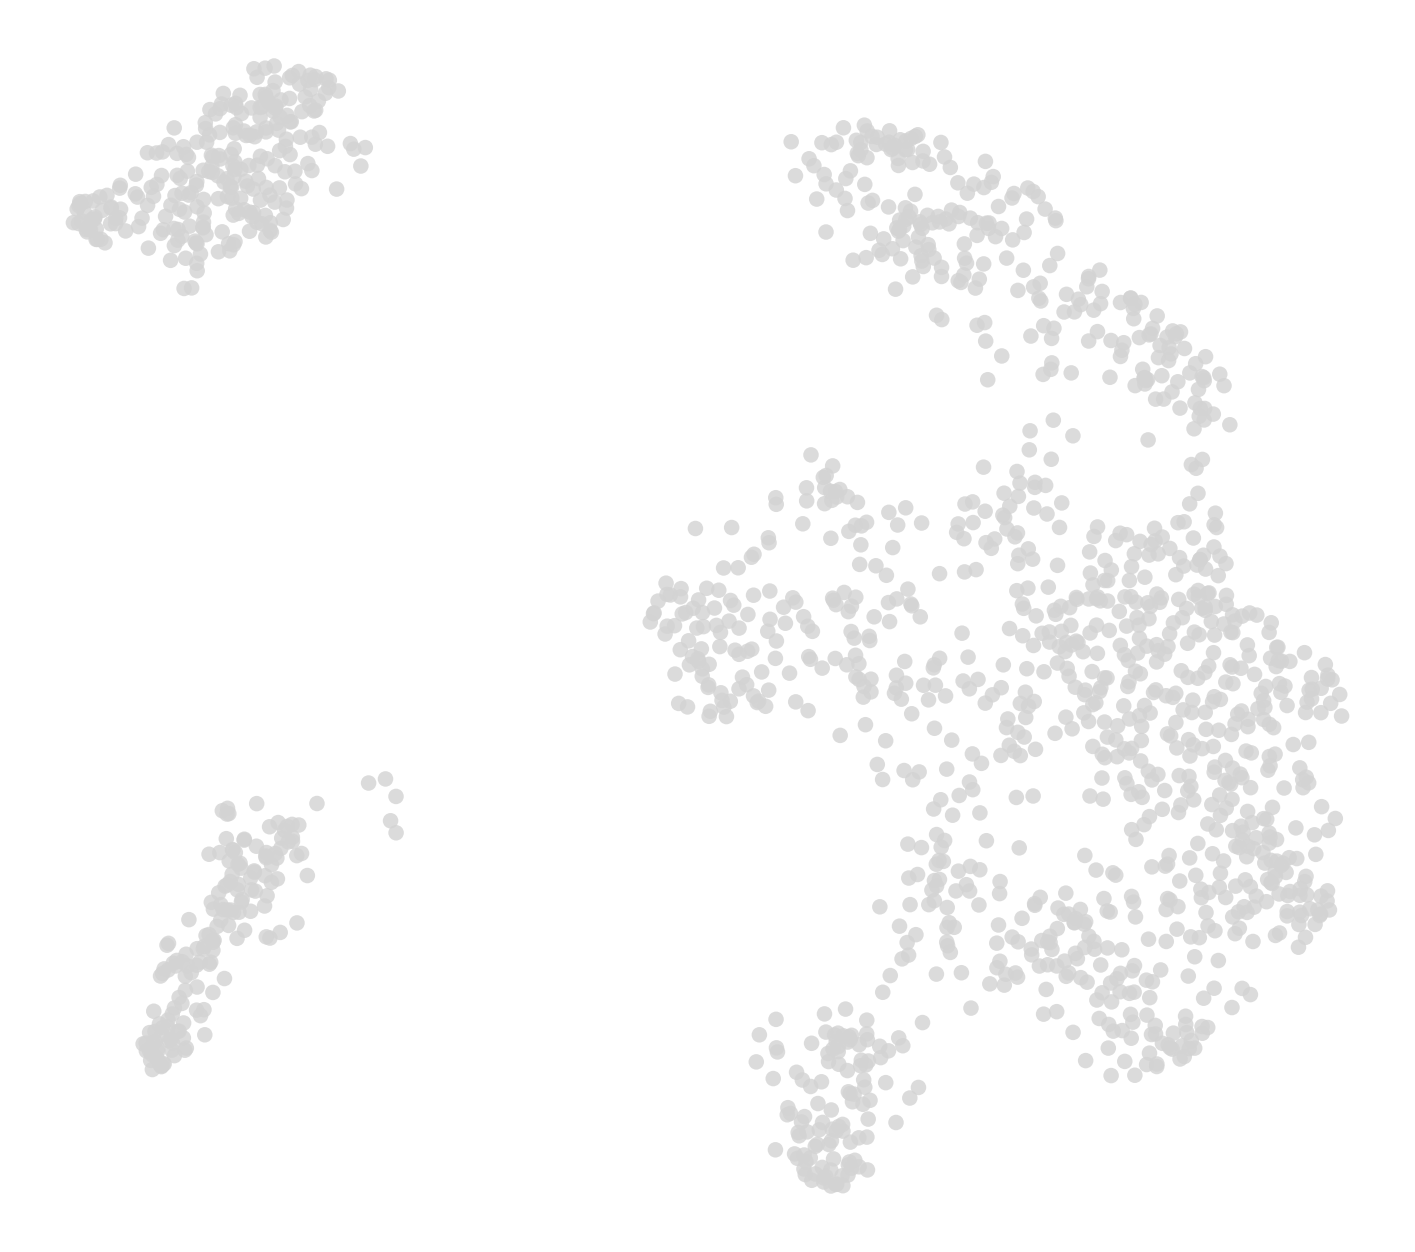

In [5]:
mult = 2
fig, ax = plt.subplots(figsize = (9*mult, 8*mult))
sc.pl.umap(adata, ax = ax, show = False,frameon = False, s = 500, title = '', alpha = 0.8)
fig.savefig(os.path.join(path, 'Notebook-Output', 'EPI_UMAP_AllGray.png'), transparent = True, bbox_inches = 'tight', dpi = 100)

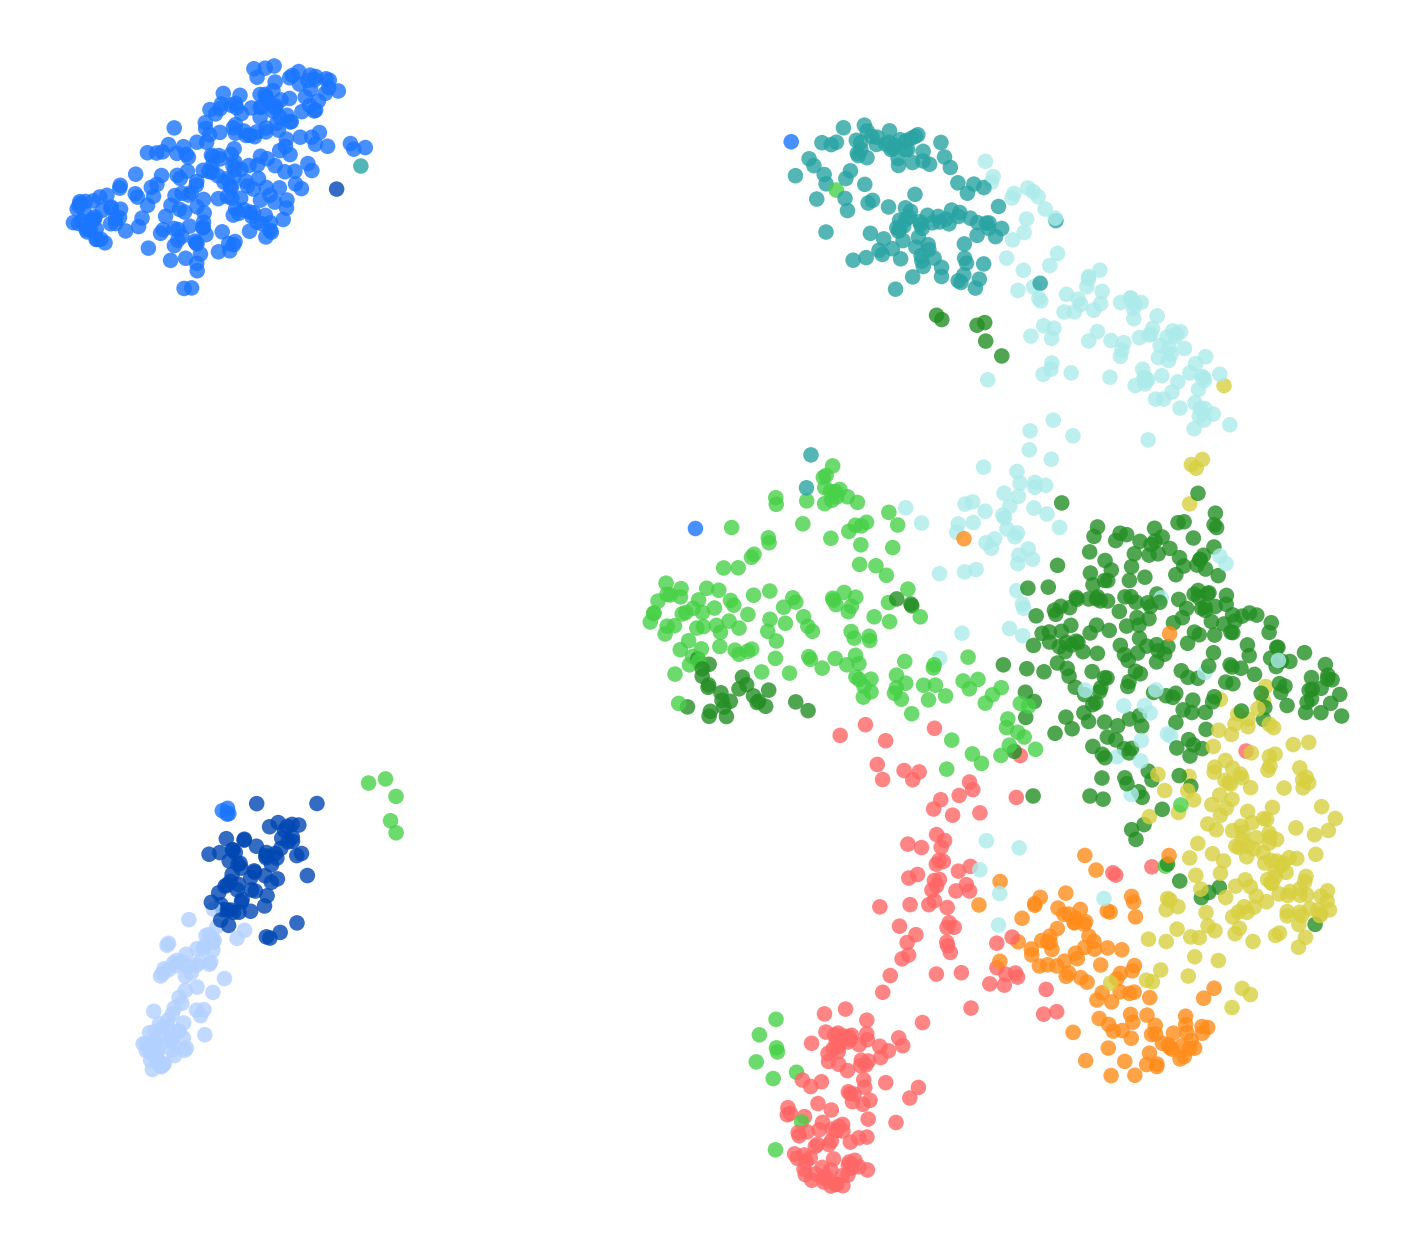

In [6]:
ult = 2
fig, ax = plt.subplots(figsize = (9*mult, 8*mult))
sc.pl.umap(adata, ax = ax, show = False,frameon = False, s = 500, title = '', alpha = 0.8,color='HC_named')
ax.legend().remove()
fig.savefig(os.path.join(path, 'Notebook-Output', 'EPI_UMAP_Clustering.png'), transparent = True, bbox_inches = 'tight', dpi = 100)

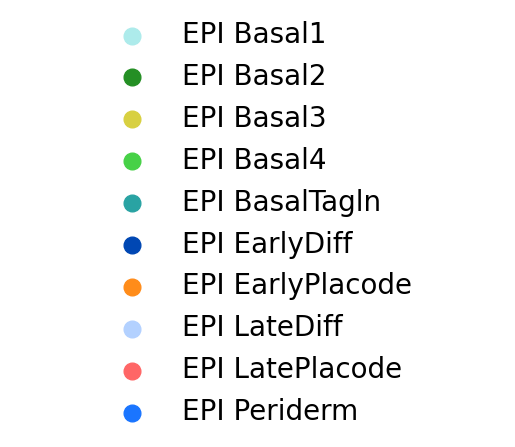

In [7]:
label_params = ax.get_legend_handles_labels()
figl, axl = plt.subplots()
axl.axis(False)
axl.legend(*label_params, loc="center", prop={"size":20},frameon=False,ncol=1,markerscale=2)
figl.savefig(os.path.join(path, 'Notebook-Output', 'EPI_UMAP_clusters_legend.png'), transparent = True, bbox_inches = 'tight', dpi = 100)

In [8]:
#Assign colors to categorical variable 'embryonic age'
adata.uns['embryonic_age_colors']=['#E00D75','#85C100','#3399C1']

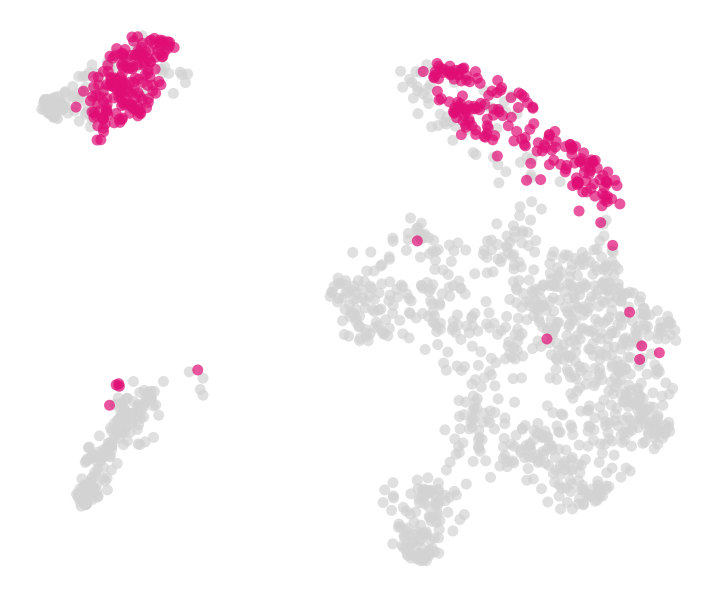

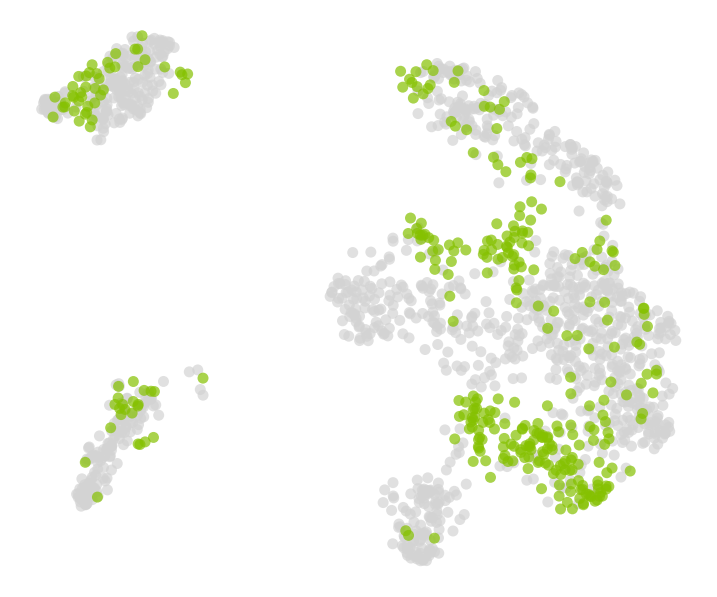

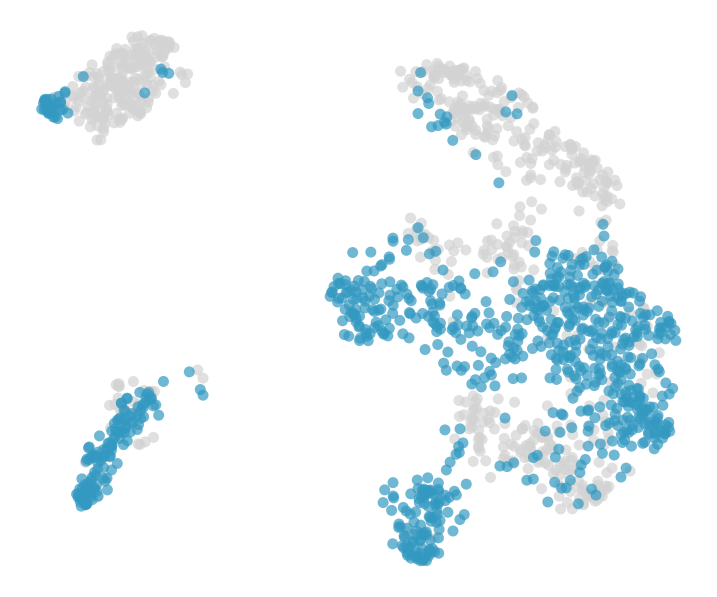

In [9]:
#Only highlight cells sampled at a specific embryonic age in color on top of a grey UMAP showing all epidermal cells
mult = 3
fig, ax = plt.subplots(figsize = (3*mult, 2.5*mult))
sc.pl.umap(adata, ax = ax, show = False, frameon = False, s = 250, title = '', alpha = 0.7,color='embryonic_age', groups=['E12.5'])
ax.legend().remove()
fig.savefig(os.path.join(path, 'Notebook-Output', 'EPI_Age_E12.png'), transparent = True, bbox_inches = 'tight', dpi = 100)

fig, ax = plt.subplots(figsize = (3*mult, 2.5*mult))
sc.pl.umap(adata, ax = ax, show = False, frameon = False, s = 250, title = '', alpha = 0.7,color='embryonic_age', groups=['E13.5'])
ax.legend().remove()
fig.savefig(os.path.join(path, 'Notebook-Output', 'EPI_Age_E13.png'), transparent = True, bbox_inches = 'tight', dpi = 100)

fig, ax = plt.subplots(figsize = (3*mult, 2.5*mult))
sc.pl.umap(adata, ax = ax, show = False, frameon = False, s = 250, title = '', alpha = 0.7,color='embryonic_age', groups=['E14.5'])
ax.legend().remove()
fig.savefig(os.path.join(path, 'Notebook-Output', 'EPI_Age_E14.png'), transparent = True, bbox_inches = 'tight', dpi = 100)

In [11]:
#Grouping epidermal subclusters into major epidermis groups for plotting purposes
naming_dict = {'EPI Basal1':'EPI BasalAll', 'EPI Basal2':'EPI BasalAll','EPI Basal3':'EPI BasalAll','EPI Basal4':'EPI BasalAll','EPI Periderm':'EPI Periderm','EPI BasalTagln':'EPI BasalAll','EPI EarlyDiff':'EPI EarlyDiff','EPI LateDiff':'EPI LateDiff','EPI EarlyPlacode':'EPI PlacodeAll','EPI LatePlacode':'EPI PlacodeAll',}
adata.obs['HC_named_grouped'] = [naming_dict[x] for x in adata.obs['HC_named']]
adata.obs['HC_named_grouped'] = adata.obs['HC_named_grouped'].astype('category')

In [12]:
#Display names of grouped epidermal subclusters
adata.obs['HC_named_grouped'].cat.categories

Index(['EPI BasalAll', 'EPI EarlyDiff', 'EPI LateDiff', 'EPI Periderm',
       'EPI PlacodeAll'],
      dtype='object')

In [13]:
#Assign colors of grouped epidermal subclusters
adata.uns['HC_named_grouped_colors'] = ['#4DB834','#0047B3','#B3D1Ff','#1A75FF','#EA411B']

In [14]:
#Grouping epidermal subclusters partially into major epidermis groups for plotting purposes
naming_dict = {'EPI Basal1':'EPI BasalAll', 'EPI Basal2':'EPI BasalAll','EPI Basal3':'EPI BasalAll','EPI Basal4':'EPI BasalAll','EPI Periderm':'EPI Periderm','EPI BasalTagln':'EPI BasalAll','EPI EarlyDiff':'EPI EarlyDiff','EPI LateDiff':'EPI LateDiff','EPI EarlyPlacode':'EPI EarlyPlacode','EPI LatePlacode':'EPI LatePlacode',}
adata.obs['HC_named_partiallygrouped'] = [naming_dict[x] for x in adata.obs['HC_named']]
adata.obs['HC_named_partiallygrouped'] = adata.obs['HC_named_partiallygrouped'].astype('category')

In [15]:
#Display names of partially grouped epidermal subclusters
adata.obs['HC_named_partiallygrouped'].cat.categories

Index(['EPI BasalAll', 'EPI EarlyDiff', 'EPI EarlyPlacode', 'EPI LateDiff',
       'EPI LatePlacode', 'EPI Periderm'],
      dtype='object')

In [16]:
#Assign colors of partially grouped epidermal subclusters
adata.uns['HC_named_partiallygrouped_colors'] = ['#4DB834','#0047B3','#FF8c1A','#B3D1Ff','#FF6666','#1A75FF']

ax = axes[ix]


/tmp/ipykernel_925872/3546929578.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)


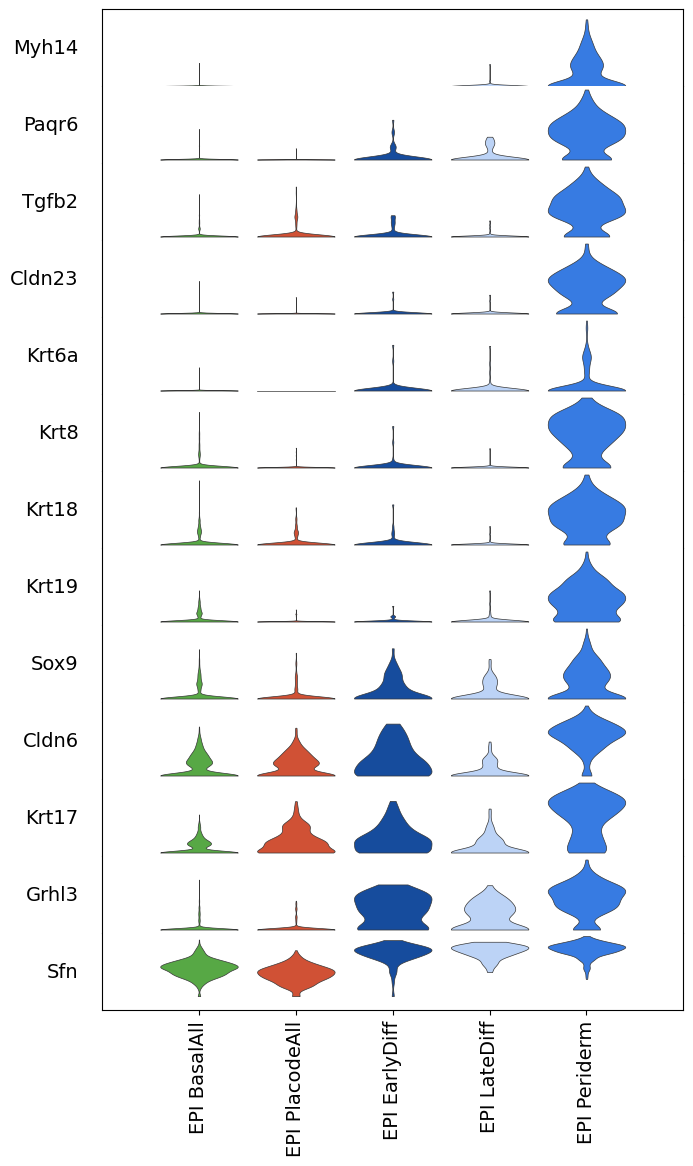

In [19]:
#Generate violin plots with marker genes setting apart the epidermal subclusters
#Note: These plots can be saved with or without labels on x and y axis

#Periderm markers
marker_genes=['Myh14','Paqr6','Tgfb2','Cldn23','Krt6a','Krt8','Krt18','Krt19','Sox9','Cldn6','Krt17','Grhl3','Sfn']
cluster_order = [ 'EPI BasalAll', 'EPI PlacodeAll', 'EPI EarlyDiff', 'EPI LateDiff', 'EPI Periderm']
layer = 'normalized'

ncols = 1
mult=3
fig, axes = initialize_subplots(len(marker_genes), ncols = ncols, figsize_multiplier=(7.5,1), gridspec_kw = {'hspace':0.0})

for ix, gene in enumerate(marker_genes):
    ax = axes[ix]
    sc.pl.violin(adata,keys=gene, groupby = 'HC_named_grouped', cut = 0, ax = ax, show = False, stripplot = False, linewidth = 0.5, layer = layer, order = cluster_order)
   
    if ix == len(marker_genes)-1:
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)
        ax.spines['top'].set_visible(False)
        ax.set_ylim([-1, ax.get_ylim()[1]])
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])
        if ix == 0:
            ax.spines['bottom'].set_visible(False)
            ax.set_ylim([0, ax.get_ylim()[1] + 0.1*ax.get_ylim()[1]])
        else:
            ax.spines['top'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
    
    ax.set_ylabel(gene, fontsize = 14, rotation = 0, labelpad = 10, horizontalalignment='right', verticalalignment='center')   #Activate if labels are desired
    #ax.set_ylabel('')            #Comment out if labels are desired
    ax.yaxis.set_ticks_position('none')      

    ax.set_yticklabels([])                                                  #If no min-max values are desired
    #ax.tick_params(axis = 'y', labelsize = 14)                             #To add min-max values on y axis
    #ax.yaxis.set_major_locator(MaxNLocator(integer = True, nbins = 2))     #To add min-max values on y axis
    #ax.set_yticks([x for x in ax.get_yticks() if x>0][:1])                 #To add min-max values on y axis
    
    ax.set_xlabel('')
    ax.set_xlim(ax.get_xlim()[0]-0.5, ax.get_xlim()[1]+0.5)
    #ax.set_xticklabels([])        #Comment out if labels are desired
    
fig.savefig(os.path.join(path, 'Notebook-Output', 'Epi_Vln_Periderm_WithXLabels.pdf'), transparent = True, bbox_inches = 'tight', dpi = 100)

ax = axes[ix]


/tmp/ipykernel_925872/3519994071.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)


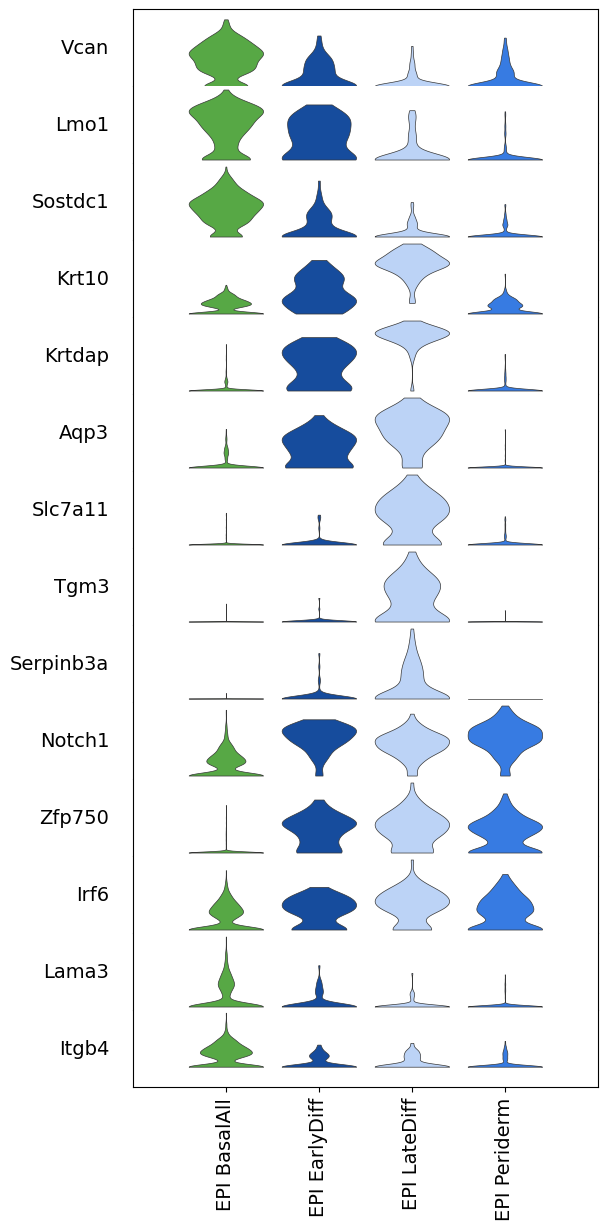

In [20]:
#Generate violin plots with marker genes setting apart the epidermal subclusters
#Note: These plots can be saved with or without labels on x and y axis

#Differentiation markers
marker_genes=['Vcan','Lmo1','Sostdc1','Krt10','Krtdap','Aqp3','Slc7a11','Tgm3','Serpinb3a','Notch1','Zfp750','Irf6','Lama3','Itgb4']
cluster_order = [ 'EPI BasalAll', 'EPI EarlyDiff', 'EPI LateDiff', 'EPI Periderm']
layer = 'normalized'

ncols = 1
mult=1
fig, axes = initialize_subplots(len(marker_genes), ncols = ncols, figsize_multiplier=(6*mult,1*mult), gridspec_kw = {'hspace':0.0})

for ix, gene in enumerate(marker_genes):
    ax = axes[ix]
    sc.pl.violin(adata,keys=gene, groupby = 'HC_named_grouped', cut = 0, ax = ax, show = False, stripplot = False, linewidth = 0.5, layer = layer, order = cluster_order)
   
    if ix == len(marker_genes)-1:
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)
        ax.spines['top'].set_visible(False)
        ax.set_ylim([-1, ax.get_ylim()[1]])
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])
        if ix == 0:
            ax.spines['bottom'].set_visible(False)
            ax.set_ylim([0, ax.get_ylim()[1] + 0.1*ax.get_ylim()[1]])
        else:
            ax.spines['top'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
    
    ax.set_ylabel(gene, fontsize = 14, rotation = 0, labelpad = 10, horizontalalignment='right', verticalalignment='center')   #Activate if labels are desired
    #ax.set_ylabel('')            #Comment out if labels are desired
    ax.yaxis.set_ticks_position('none')      

    ax.set_yticklabels([])                                                  #If no min-max values are desired
    #ax.tick_params(axis = 'y', labelsize = 14)                             #To add min-max values on y axis
    #ax.yaxis.set_major_locator(MaxNLocator(integer = True, nbins = 2))     #To add min-max values on y axis
    #ax.set_yticks([x for x in ax.get_yticks() if x>0][:1])                 #To add min-max values on y axis
    
    ax.set_xlabel('')
    ax.set_xlim(ax.get_xlim()[0]-0.5, ax.get_xlim()[1]+0.5)
    #ax.set_xticklabels([])        #Comment out if labels are desired    
    
fig.savefig(os.path.join(path, 'Notebook-Output', 'Epi_Vln_Differentiation_WithLabels.pdf'), transparent = True, bbox_inches = 'tight', dpi = 100)

ax = axes[ix]


/tmp/ipykernel_925872/1243512153.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)


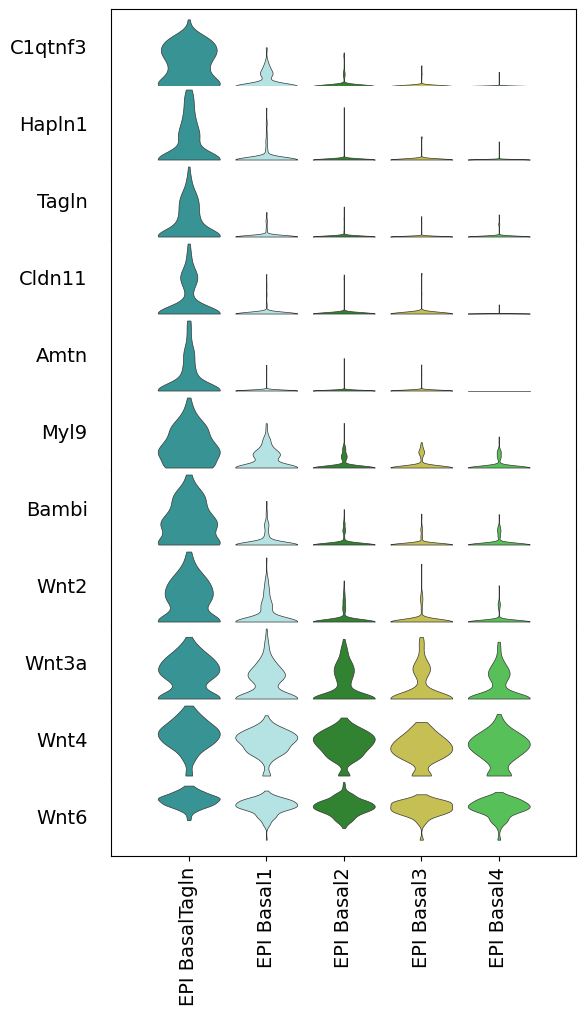

In [21]:
#Generate violin plots with marker genes setting apart the epidermal subclusters
#Note: These plots can be saved with or without labels on x and y axis

#BasalTagln markers
marker_genes=['C1qtnf3','Hapln1','Tagln','Cldn11','Amtn','Myl9','Bambi','Wnt2','Wnt3a','Wnt4','Wnt6']
cluster_order = [ 'EPI BasalTagln', 'EPI Basal1', 'EPI Basal2', 'EPI Basal3', 'EPI Basal4']
layer = 'normalized'

ncols = 1
mult=1
fig, axes = initialize_subplots(len(marker_genes), ncols = ncols, figsize_multiplier=(6*mult,1*mult), gridspec_kw = {'hspace':0.0})

for ix, gene in enumerate(marker_genes):
    ax = axes[ix]
    sc.pl.violin(adata,keys=gene, groupby = 'HC_named', cut = 0, ax = ax, show = False, stripplot = False, linewidth = 0.5, layer = layer, order = cluster_order)
   
    if ix == len(marker_genes)-1:
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)
        ax.spines['top'].set_visible(False)
        ax.set_ylim([-1, ax.get_ylim()[1]])
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])
        if ix == 0:
            ax.spines['bottom'].set_visible(False)
            ax.set_ylim([0, ax.get_ylim()[1] + 0.1*ax.get_ylim()[1]])
        else:
            ax.spines['top'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
    
    ax.set_ylabel(gene, fontsize = 14, rotation = 0, labelpad = 10, horizontalalignment='right', verticalalignment='center')   #Activate if labels are desired
    #ax.set_ylabel('')            #Comment out if labels are desired
    ax.yaxis.set_ticks_position('none')      

    ax.set_yticklabels([])                                                  #If no min-max values are desired
    #ax.tick_params(axis = 'y', labelsize = 14)                             #To add min-max values on y axis
    #ax.yaxis.set_major_locator(MaxNLocator(integer = True, nbins = 2))     #To add min-max values on y axis
    #ax.set_yticks([x for x in ax.get_yticks() if x>0][:1])                 #To add min-max values on y axis
    
    ax.set_xlabel('')
    ax.set_xlim(ax.get_xlim()[0]-0.5, ax.get_xlim()[1]+0.5)
    #ax.set_xticklabels([])        #Comment out if labels are desired    
    
fig.savefig(os.path.join(path, 'Notebook-Output', 'Epi_Vln_Tagln_WithLabels.pdf'), transparent = True, bbox_inches = 'tight', dpi = 100)

ax = axes[ix]


/tmp/ipykernel_925872/3891835854.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)


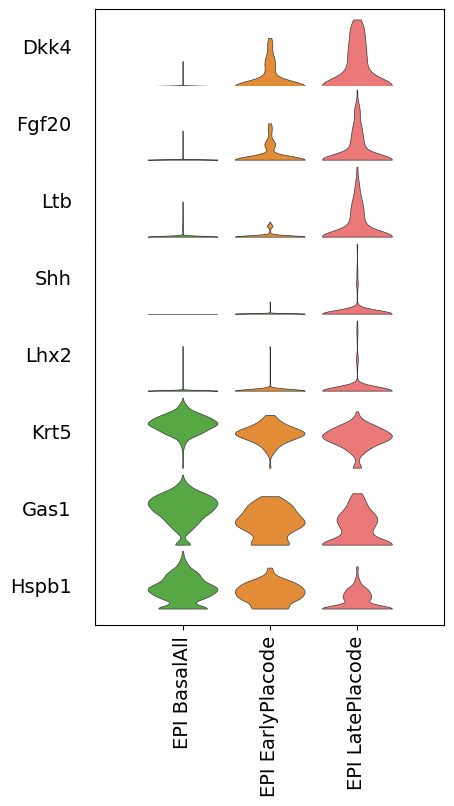

In [22]:
#Generate violin plots with marker genes setting apart the epidermal subclusters
#Note: These plots can be saved with or without labels on x and y axis

#Placode markers
marker_genes=['Dkk4','Fgf20','Ltb','Shh','Lhx2','Krt5','Gas1','Hspb1']
cluster_order = [ 'EPI BasalAll', 'EPI EarlyPlacode','EPI LatePlacode']
layer = 'normalized'

ncols = 1
mult=1
fig, axes = initialize_subplots(len(marker_genes), ncols = ncols, figsize_multiplier=(4.5*mult,1*mult), gridspec_kw = {'hspace':0.0})

for ix, gene in enumerate(marker_genes):
    ax = axes[ix]
    sc.pl.violin(adata,keys=gene, groupby = 'HC_named_partiallygrouped', cut = 0, ax = ax, show = False, stripplot = False, linewidth = 0.5, layer = layer, order = cluster_order)
   
    if ix == len(marker_genes)-1:
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)
        ax.spines['top'].set_visible(False)
        ax.set_ylim([-1, ax.get_ylim()[1]])
    else:
        ax.set_xticklabels([])
        ax.set_xticks([])
        if ix == 0:
            ax.spines['bottom'].set_visible(False)
            ax.set_ylim([0, ax.get_ylim()[1] + 0.1*ax.get_ylim()[1]])
        else:
            ax.spines['top'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
    
    ax.set_ylabel(gene, fontsize = 14, rotation = 0, labelpad = 10, horizontalalignment='right', verticalalignment='center')   #Activate if labels are desired
    #ax.set_ylabel('')            #Comment out if labels are desired
    ax.yaxis.set_ticks_position('none')      

    ax.set_yticklabels([])                                                  #If no min-max values are desired
    #ax.tick_params(axis = 'y', labelsize = 14)                             #To add min-max values on y axis
    #ax.yaxis.set_major_locator(MaxNLocator(integer = True, nbins = 2))     #To add min-max values on y axis
    #ax.set_yticks([x for x in ax.get_yticks() if x>0][:1])                 #To add min-max values on y axis
    
    ax.set_xlabel('')
    ax.set_xlim(ax.get_xlim()[0]-0.5, ax.get_xlim()[1]+0.5)
    #ax.set_xticklabels([])        #Comment out if labels are desired
    
fig.savefig(os.path.join(path, 'Notebook-Output', 'Epi_Vln_Placode_WithLabels.pdf'), transparent = True, bbox_inches = 'tight', dpi = 100)

In [30]:
#Generate color bar for plotting gene expression levels on top of UMAP
colors = [(0.8, 0.8, 0.8), (0.19, 0.04, 0.55)] # first color is grey, last is dark purple
cm = LinearSegmentedColormap.from_list("Custom", colors, N=200)

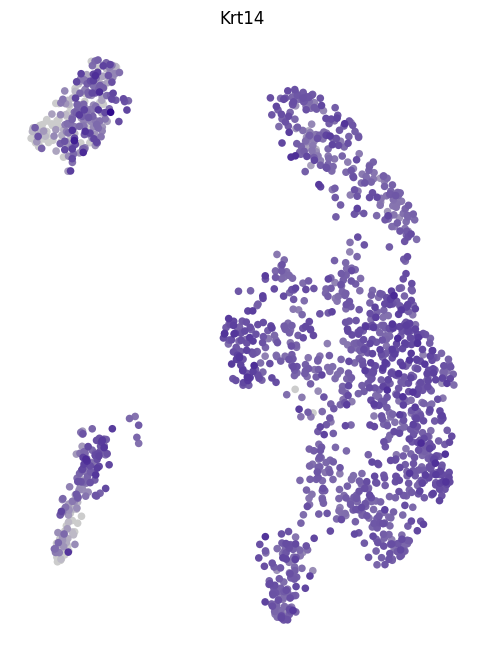

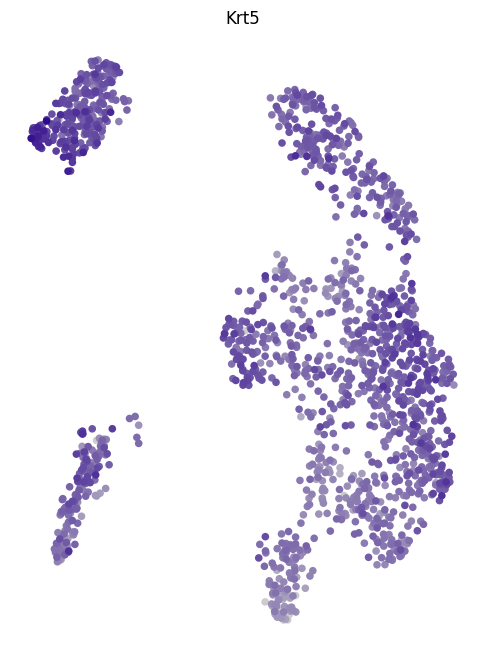

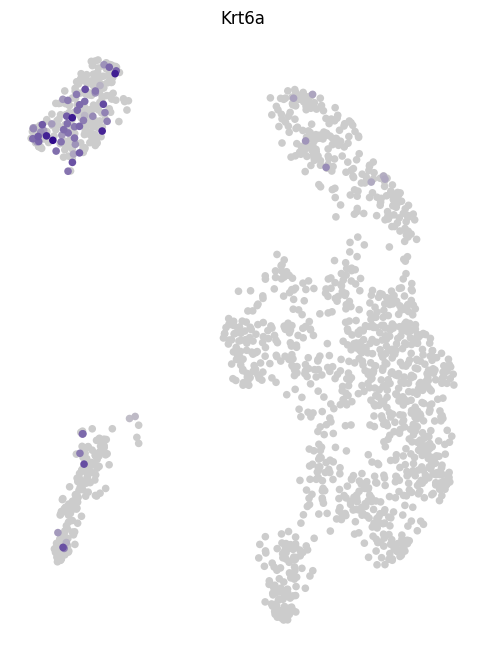

In [35]:
genelist = ['Krt14', 'Krt5', 'Krt6a']
mult = 4
outdir = "./ExpressionPlots"
os.makedirs(outdir, exist_ok=True)

for gene in genelist:
    fig, ax = plt.subplots(figsize=(1.5*mult, 2*mult))
    sc.pl.umap(
        adata,
        color=gene,
        layer='normalized',
        ax=ax,
        show=False,
        frameon=False,
        s=120,
        title=gene,
        alpha=1,
        color_map=cm
    )
    ax.collections[-1].colorbar.remove()

    fig.savefig(
        os.path.join(outdir, f"Epi_Expression_{gene}.pdf"),
        bbox_inches='tight',
        transparent=True
    )
    plt.show()

# 3 Extract Krt14 and Krt5 expression matrix

# 3.1 Extract normalized data

In [25]:
genes = ["Krt5", "Krt14"]

# 取 normalized 层
expr = adata[:, genes].layers["normalized"]

# 如果是稀疏矩阵，转成普通数组
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()

expr_df = pd.DataFrame(expr, index=adata.obs_names, columns=genes)

# 加一些你后面大概率会用到的注释
meta_df = adata.obs[["embryonic_age", "HC_named", "genotype", "sample_id"]].copy()

out_df = pd.concat([meta_df, expr_df], axis=1)
out_df.index.name = "cell_id"

out_df.to_csv("Adata-object_Epi_Krt5_Krt14_normalized_expression.csv")
out_df.head()

,embryonic_age,HC_named,genotype,sample_id,Krt5,Krt14
cell_id,,,,,,
AAAGTAGAGGGAACGG_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,2.351274,2.955238
AACACGTCAATGGATA_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,1.613611,2.569763
AACTGGTAGGTGCTTT_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,2.223610,2.223610
AAGACCTTCTAACGGT_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,2.589937,2.970076
AAGGAGCAGCAGACTG_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,3.101876,0.000000


## 3.2 Extract raw data

In [26]:
expr_raw = adata[:, genes].layers["raw"]

if not isinstance(expr_raw, np.ndarray):
    expr_raw = expr_raw.toarray()

expr_raw_df = pd.DataFrame(expr_raw, index=adata.obs_names, columns=[g + "_raw" for g in genes])

out_raw_df = pd.concat([meta_df, expr_raw_df], axis=1)
out_raw_df.index.name = "cell_id"

out_raw_df.to_csv("Adata-object_Epi_Krt5_Krt14_raw_expression.csv")
out_raw_df.head()

,embryonic_age,HC_named,genotype,sample_id,Krt5_raw,Krt14_raw
cell_id,,,,,,
AAAGTAGAGGGAACGG_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,12.0,23.0
AACACGTCAATGGATA_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,1.0,3.0
AACTGGTAGGTGCTTT_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,2.0,2.0
AAGACCTTCTAACGGT_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,20.0,30.0
AAGGAGCAGCAGACTG_10x_17_033_12,E12.5,EPI Periderm,WT,10x_17_033_12,11.0,0.0


In R, we will analyze the correlation between krt14 and krt5 using normalized matrix